## Introduction 

In this script, the local closeness per ward is computed. 

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [2]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [3]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [4]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [5]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 369 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [6]:
G = ox.io.load_graphml(path_graphml)

In [7]:
G.graph["crs"]

'epsg:4326'

In [8]:
df.crs.to_epsg()

4326

## Computing (local) closeness at the ward level

In [13]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'closeness_local'])
results

,ward_id,ward_name,Corporatio,closeness_local


In [14]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, radius = 500, name='closeness_500', distance='mm_len', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_500'].mean()

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        closeness_mean
    ]
    

Processing wards:   0%|                                                                                                                                                                   | 0/369 [00:00<?, ?it/s]

  0%|          | 0/823 [00:00<?, ?it/s]

Processing wards:   0%|▍                                                                                                                                                        | 1/369 [00:14<1:26:53, 14.17s/it]

  0%|          | 0/1352 [00:00<?, ?it/s]

Processing wards:   1%|▊                                                                                                                                                        | 2/369 [00:27<1:23:55, 13.72s/it]

...

Processing wards:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 367/369 [1:20:18<00:29, 14.72s/it]

  0%|          | 0/238 [00:00<?, ?it/s]

Processing wards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌| 368/369 [1:20:29<00:13, 13.69s/it]

  0%|          | 0/173 [00:00<?, ?it/s]

Processing wards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [1:20:39<00:00, 13.12s/it]


In [15]:
results

,ward_id,ward_name,Corporatio,closeness_local
0,25,25 - Vinayaka Layout,West,0.000321
1,2,2 - Aerocity,North,0.000146
2,3,3 - Chowdeshwari ward,North,0.000185
3,15,15 - Ramamurthy Nagara,East,0.000882
4,58,58 - Nagashettyhalli,North,0.000796
...,...,...,...,...
364,56,56 - Gopalpura,Central,0.000521
365,57,57 - Cottonpete,Central,0.001096
366,54,54 - Binnypete,Central,0.001290
367,47,47 - IPD Salappa Ward,Central,0.001219


In [17]:
top10_highest = (
    results
    .sort_values(by='closeness_local', ascending=False)
    .head(10)
)
top10_highest

,ward_id,ward_name,Corporatio,closeness_local
274,39,39 - Venkat Reddy Nagara,Central,0.002889
184,88,88 - Sangolli Rayanna Ward,West,0.002680
258,46,46 - Cheluvadi Palya,Central,0.002661
26,51,51 - Old Guddadahalli,Central,0.002609
198,58,58 - Dayanand Nagara,West,0.002585
233,28,28 - Neelasandra,Central,0.002582
159,65,65 - Manjunath Nagara,West,0.002533
42,3,3 - Yarab nagar,South,0.002527
56,53,53 - Rayapuram,Central,0.002524
60,52,52 - Padarayanapura,Central,0.002390


In [18]:
top10_lowest = (
    results
    .sort_values(by='closeness_local', ascending=True)
    .head(10)
)
top10_lowest

,ward_id,ward_name,Corporatio,closeness_local
53,52,52 - Talagattapura,South,0.000079
18,20,20 - Kengeri Kote ward,West,0.000081
57,40,40 - Anjanapura,South,0.000088
5,21,21 - Kogilu,North,0.000094
185,20,20 - Sampigehalli,North,0.000102
238,50,50 - Gunjur,East,0.000114
130,31,31 - Kasavanahalli,South,0.000116
34,2,2 - Horamavu,East,0.000116
63,51,51 - Subramanyapura,South,0.000121
7,24,24 - Agaram,Central,0.000122


In [19]:
print(f'The mean of the local closeness across the wards is {results["closeness_local"].mean()}.')
print(f'The minimum of the local closeness across the wards is {results["closeness_local"].min()}.')
print(f'The maximum of the local closeness across the wards is {results["closeness_local"].max()}.')

The mean of the global closeness across the wards is 0.0008080999063660105.
The minimum of the global closeness across the wards is 7.875404956949632e-05.
The maximum of the global closeness across the wards is 0.002889140782518148.


In [20]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_local_closeness_all_roads.csv"

results.to_csv(results_path)

In [21]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_bangalore_local_closeness_all_roads.csv"
results = pd.read_csv(results_path)

In [22]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness_local
0,0,25,25 - Vinayaka Layout,West,0.000321
1,1,2,2 - Aerocity,North,0.000146
2,2,3,3 - Chowdeshwari ward,North,0.000185
3,3,15,15 - Ramamurthy Nagara,East,0.000882
4,4,58,58 - Nagashettyhalli,North,0.000796
...,...,...,...,...,...
364,364,56,56 - Gopalpura,Central,0.000521
365,365,57,57 - Cottonpete,Central,0.001096
366,366,54,54 - Binnypete,Central,0.001290
367,367,47,47 - IPD Salappa Ward,Central,0.001219


In [23]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,Unnamed: 0,ward_id_y,Corporatio_y,closeness_local
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,25,West,0.000321
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,2,North,0.000146
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,3,North,0.000185
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,15,East,0.000882
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,58,North,0.000796
...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,56,Central,0.000521
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,57,Central,0.001096
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,54,Central,0.001290
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,47,Central,0.001219


In [26]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'closeness_local']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,closeness_local
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0.000321
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",0.000146
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",0.000185
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",0.000882
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",0.000796
...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",0.000521
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",0.001096
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",0.001290
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",0.001219


In [27]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

## Plots

Plot the local closeness at the wards:

In [30]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_local_all_roads_bangalore.png'

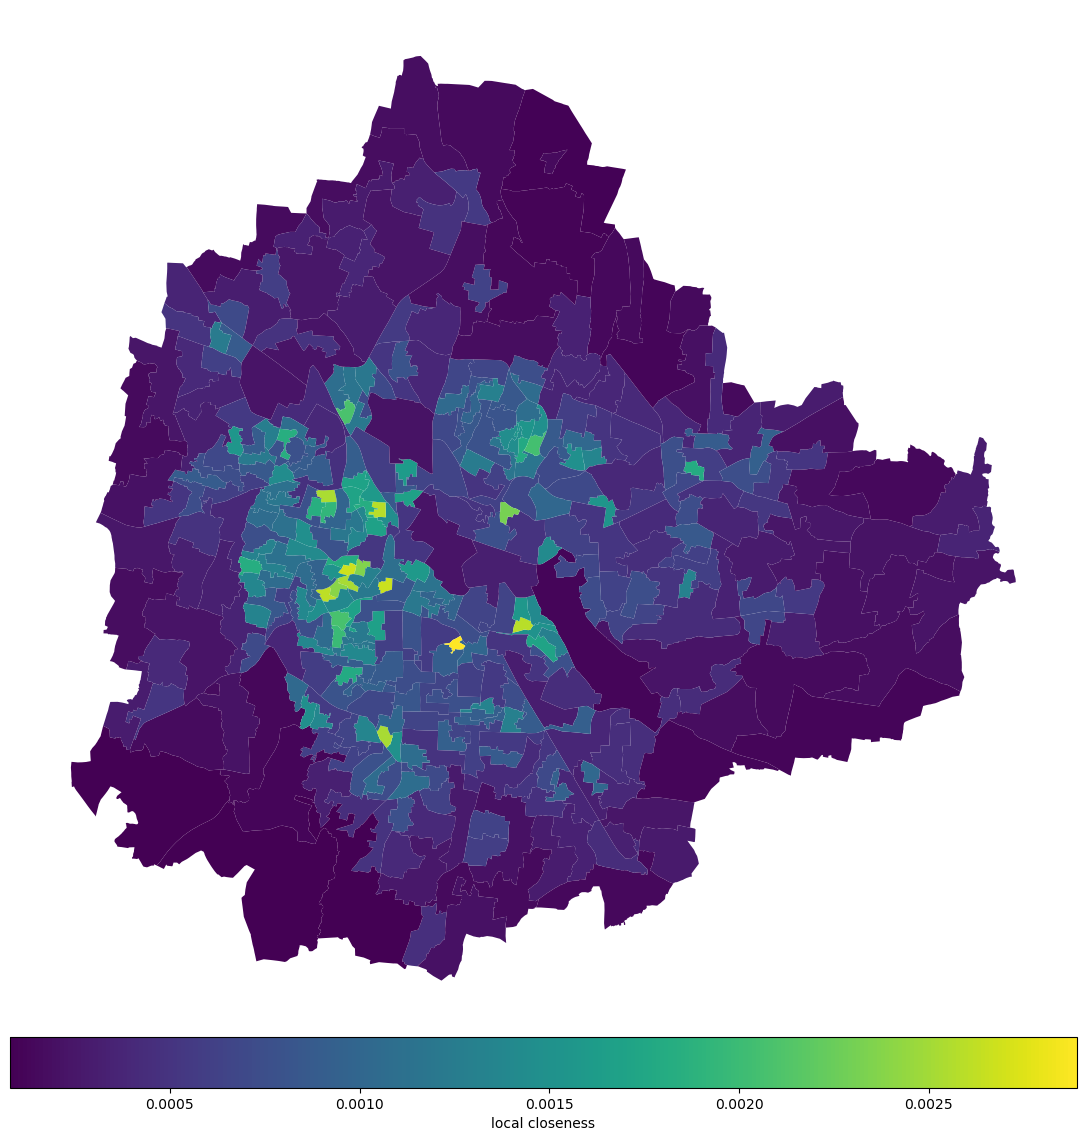

In [32]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness_local",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "local closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()